1. First-Order System :$$\tau \dot{V}(t) = -V(t) + u(t)$$Where:$V(t)$: state of the system (population voltage in our context)$u(t)$: external driver (firing rate of other populations)$\tau$: time constant2. Discretization via Euler MethodBased on the second image:We discretize continuous time using the Euler methodThere is a single state variable called $V(t)$At each step, we perform the following update:$$V(t + dt) = V(t) + \frac{dt}{\tau}(-V(t) + u(t))$$
2.  Building a 2nd-order system via velocity Now let's not break the same logic. Let's define a new variable:$$W(t) = \dot{V}(t)$$That is:$V$: think of it as position$W$: velocity Now we have two 1st-order equations.
3. Velocity form of a 2nd-order ODEThe classic 2nd-order equation:$$\ddot{V} + a\dot{V} + bV = u(t)$$is equivalent to:$$\begin{cases} 
\dot{V} = W \\ 
\dot{W} = -aW - bV + u(t) 
\end{cases}$$

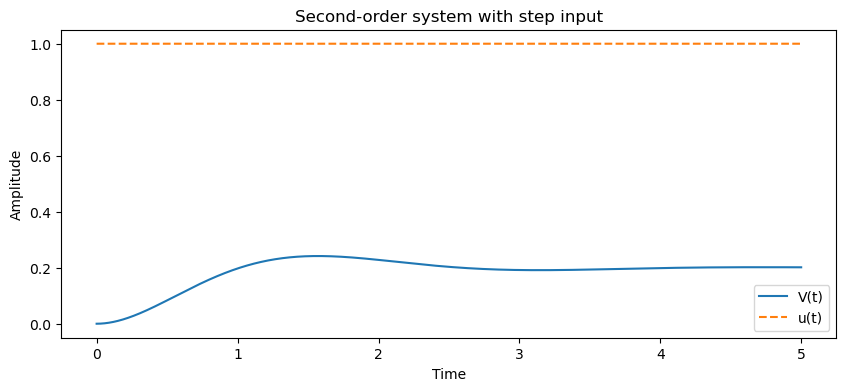

In [2]:
import numpy as np
import matplotlib.pyplot as plt


dt = 0.001
t = np.arange(0, 5, dt)


a = 2.0   
b = 5.0   

# constant input
u = np.ones_like(t)


V = np.zeros_like(t)  
W = np.zeros_like(t)  


for i in range(1, len(t)):
    dV = W[i-1]
    dW = -a * W[i-1] - b * V[i-1] + u[i]

    V[i] = V[i-1] + dt * dV
    W[i] = W[i-1] + dt * dW


plt.figure(figsize=(10, 4))
plt.plot(t, V, label="V(t)")
plt.plot(t, u, "--", label="u(t)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Second-order system with step input")
plt.legend()
plt.show()


In Step Input: overshoot + settling

In Sinusoids: certain frequencies pass more strongly (resonance)

This is no longer purely low-pass.

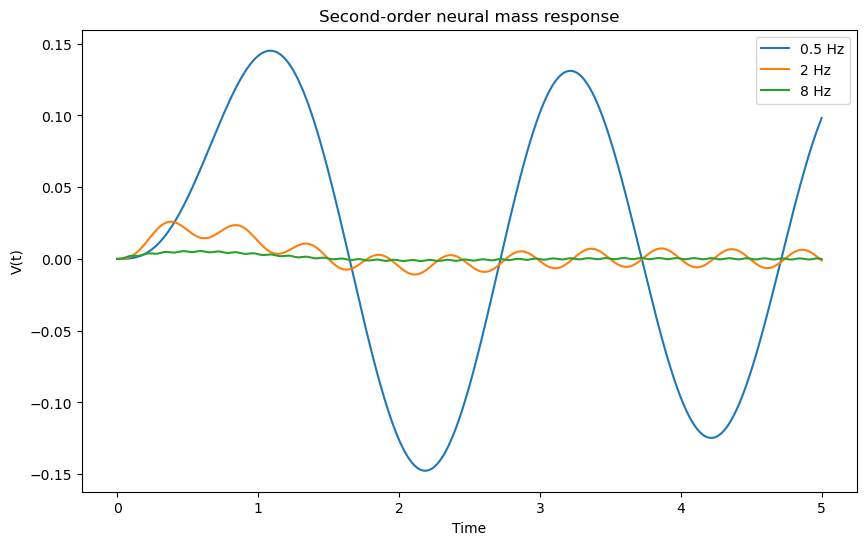

In [6]:
dt = 0.001
t = np.arange(0, 5, dt)


a = 2.0
b = 5.0

freqs = [0.5, 2, 8]  

plt.figure(figsize=(10, 6))

for f in freqs:
    u = np.sin(2 * np.pi * f * t)

    V = np.zeros_like(t)
    W = np.zeros_like(t)

    for i in range(1, len(t)):
        dV = W[i-1]
        dW = -a * W[i-1] - b * V[i-1] + u[i]

        V[i] = V[i-1] + dt * dV
        W[i] = W[i-1] + dt * dW

    plt.plot(t, V, label=f"{f} Hz")

plt.xlabel("Time")
plt.ylabel("V(t)")
plt.title("Second-order neural mass response")
plt.legend()
plt.show()

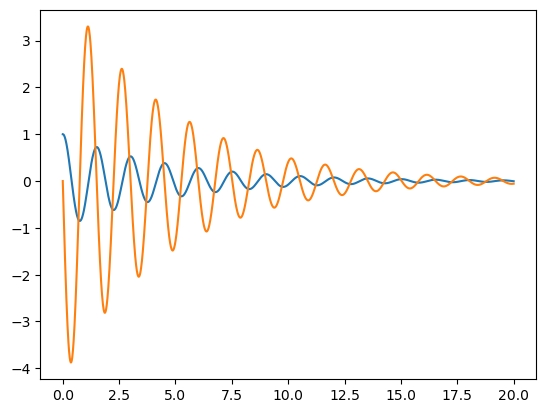

In [11]:
N=2000
dt = 0.01

V = np.zeros(N)
W=np.zeros(N)
u=np.zeros(N)
a=0.6
b = (2*np.pi*0.5)**2.5
V[0]=1

time=np.linspace(0,N*dt,N)

#

for i in range(0,N-1):
  V[i+1]=V[i]+(dt*W[i])
  W[i+1]=W[i]+(dt*((-a*W[i])-(b*V[i])+u[i]))

plt.plot(time,V)
plt.plot(time,W)

Set $u$ to zero$\rightarrow$ does the system decay completely and stop?
Decrease $a$$\rightarrow$ do you get longer oscillations?Increase $b$$\rightarrow$ does the frequency increase?If the answer to all is "yes" we are on the correct path

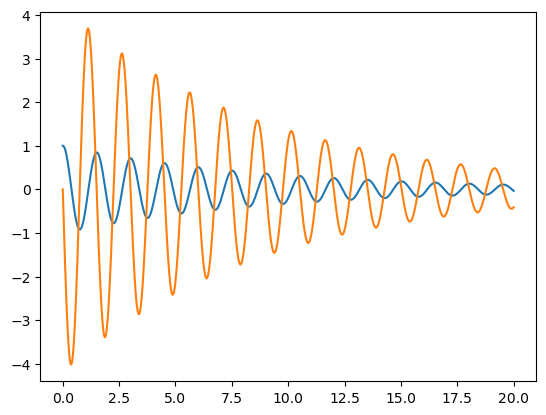

In [15]:
a=0.4

for i in range(0,N-1):
  V[i+1]=V[i]+(dt*W[i])
  W[i+1]=W[i]+(dt*((-a*W[i])-(b*V[i])+u[i]))

plt.plot(time,V)
plt.plot(time,W)

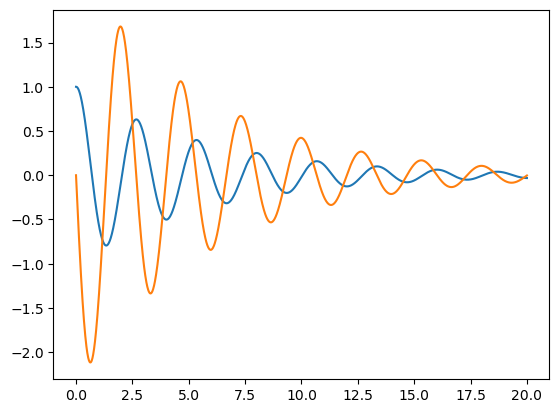

In [16]:
b = (2*np.pi*0.5)**1.5

for i in range(0,N-1):
  V[i+1]=V[i]+(dt*W[i])
  W[i+1]=W[i]+(dt*((-a*W[i])-(b*V[i])+u[i]))

plt.plot(time,V)
plt.plot(time,W)

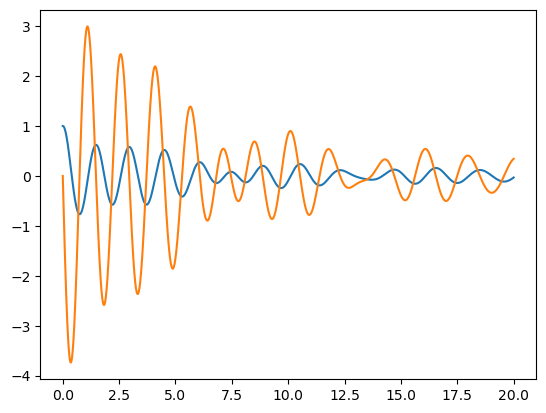

In [10]:
u = np.sin(2*np.pi*0.5*time)

for i in range(0,N-1):
  V[i+1]=V[i]+(dt*W[i])
  W[i+1]=W[i]+(dt*((-a*W[i])-(b*V[i])+u[i]))

plt.plot(time,V)
plt.plot(time,W)